# m12
Se cree que el parametro $m_{12}$ podria ser fine tunned, existen valores conocidos en rangos muy especificos;
se desea conocer si en distintas variaciones de 
- $m_\phi; m_A=m_{H^\pm}$
- $\lambda_7=0$ y $\lambda_6=10^{-\{1,2,3,4\}}$
que rangos o zonas importantes del espacio parametrico el parametro $m_{12}$ aporta estabilidad

## recomendaciones
Se puede observar que a partir de conocer $\vec m$ y $m_{12}$ esto corresponde a una combinacion: $\vec \lambda$; se ha observado que la perturbatividad es la primera en perderse, observandose con valores de $\lambda$ grandes; comunmente estos deben de encontrarse $|\lambda|<16\pi$, sin embargo dado que esta condicion proviene de expresiones de autovalores, la cantidad puede ser menor sin embargo escalara proporcionalmente a alguna potencial de $\lambda$ por tanto acaba siendo util observar como una metrica de perturbatividad a una combinacion lineal de potencias de $\lambda$


## Parametros de los ejemplos
 mh mH mA mHp sin(beta-alpha) lambda_6 lambda_7 m_12^2 tan_beta yukawas_type output_filename
mH -> 	mphi = [200, 240]
	mA = 300
	sin(beta-alpha) = 1
	lambda6 = 1e-4
	lambda7 = 0
	tan_beta = 10000000 --> beta = 1.570796226794897 (Pi/2 - 1e-7)
	alpha = 1e-7

In [9]:
# file: analysis_pipeline.py

from lib.advanced.calling_utils import OracleExecutor
from lib.oracle import run_oracle, run_oracle_batch, safe_run_oracle
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1) Crear el executor
# --------------------------------------------------
# Usa por defecto run_oracle y run_oracle_batch; ajusta nthreads si quieres
executor = OracleExecutor(
    model_fn=run_oracle,
    batch_fn=run_oracle_batch,
    nthreads=4
)

# --------------------------------------------------
# 2) Reescribir physpoint usando OracleExecutor.run
# --------------------------------------------------
# parámetros globales
lambda6   = 0.1
lambda7   = 0.0
sin_ba    = 1.0
tan_beta  = 1e4

def physpoint(mphi: float, m12_2: float, mA: float = 300.0):
    """
    Llama internalmente a executor.run y devuelve el dict estandarizado.
    """
    params = [mphi, mA, sin_ba, tan_beta, lambda6, lambda7, m12_2]
    return executor.run(params)

# --------------------------------------------------
# 3) Definir loss basado en physpoint
# --------------------------------------------------
def loss(mphi: float, m12_2: float, mA: float = 300.0) -> float:
    out = physpoint(mphi, m12_2, mA)
    # Si hay error, devolvemos un loss grande
    if out.get('error') is not None:
        return np.inf
    # Suma de lambdas como métrica
    return (
        abs(out['lambda1']) + abs(out['lambda2']) +
        abs(out['lambda3']) + abs(out['lambda4']) +
        abs(out['lambda5'])
    )

def loss_results(out) -> float:
    if out.get('error') is not None:
        return np.inf
    # Suma de lambdas como métrica
    return (
        abs(out['lambda1']) + abs(out['lambda2']) +
        abs(out['lambda3']) + abs(out['lambda4']) +
        abs(out['lambda5'])
    )



In [ ]:
# a) Secuencial (una sola llamada)
print("=== Single call ===")
single_out = executor.run([125, 300, sin_ba, tan_beta, lambda6, lambda7, 0.1])
print(single_out)

# b) Batch (usa el backend C++ con 4 hilos)
print("\n=== Batch call ===")
param_list = [
    [130 + i*5, 300.0, sin_ba, tan_beta, lambda6, lambda7, 0.01*i]
    for i in range(5)
]
batch_outs = executor.run_batch(param_list)
print("['positivity_ok']  ['unitarity_ok']  ['perturbativity_ok']  'error'")
for o in batch_outs:
    print(o['positivity_ok'], o['unitarity_ok'], o['perturbativity_ok'], o.get('error'))

# c) Parallel threading (Python threads, útil si tu model_fn es Python puro)
print("\n=== ThreadPool map ===")
thread_outs = executor.map(param_list, use_threads=True)
print("Got", len(thread_outs), "results")



=== Single call ===
{'positivity_ok': 1, 'unitarity_ok': 0, 'perturbativity_ok': 0, 'w_h2_bb': 0.0, 'w_h2_tautau': 0.0, 'w_h2_uu': 0.0, 'w_h2_du': 0.0, 'w_h2_ln': 0.0, 'w_h2_vv': [0.01661695083253746, 0.0, 0.0], 'w_h2_gaga': 0.01661695083253746, 'w_h2_Zga': 0.001589125547134468, 'w_h2_gg': 0.0, 'w_h2_hh': 0.0, 'w_total_h2': 0.01820607637967192, 'w_total_top': 1.338069402459526, 'branching_ratio_h2_gaga': 0.9127145512303347, 'lambda1': 24122383.23009194, 'lambda2': 0.2577337950288613, 'lambda3': 2.952593328048808, 'lambda4': -1.468056682578211, 'lambda5': -1.468056682578211, 'lambda6': 0.1, 'lambda7': 0.0}

=== Batch call ===
['positivity_ok']  ['unitarity_ok']  ['perturbativity_ok']  'error'
1 0 0 None
1 0 0 None
1 0 0 None
1 0 0 None
1 0 0 None

=== ThreadPool map ===
Got 5 results


In [10]:
# --------------------------------------------------
# 5) Graficar loss vs m12 para mphi fijo
# --------------------------------------------------
mphi_vals = np.linspace(130, 150, 50)
m12_vals  = np.linspace(0.0, 0.02, 50)
# formar una malla y calcular loss en batch
mesh = [[m, x] for m in mphi_vals for x in m12_vals]
# convertir a llamadas al executor.map
param_mesh = [[m, 300.0, sin_ba, tan_beta, lambda6, lambda7, x] for m, x in mesh]
results = executor.map(param_mesh, use_threads=False)


In [ ]:
# # # extraccion de funciones de perdida
losses = np.array([loss_results(out) 
                    for out in results])  # o calculas dallí mismo

# 2) Reconstruir la matriz (filas = mphi, columnas = m12)
loss_mat = losses.reshape(len(mphi_vals), len(m12_vals))


2025-04-28 03:02:41,129 [DEBUG] locator: <matplotlib.ticker.AutoLocator object at 0x7f2149f31250>


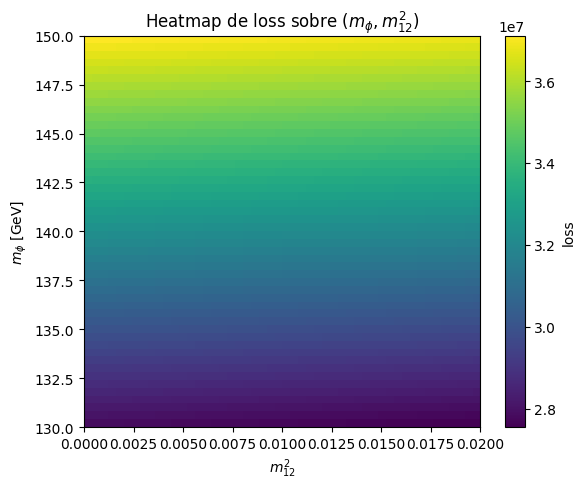

2025-04-28 03:02:42,426 [DEBUG] locator: <matplotlib.ticker.FixedLocator object at 0x7f2149cfa0d0>


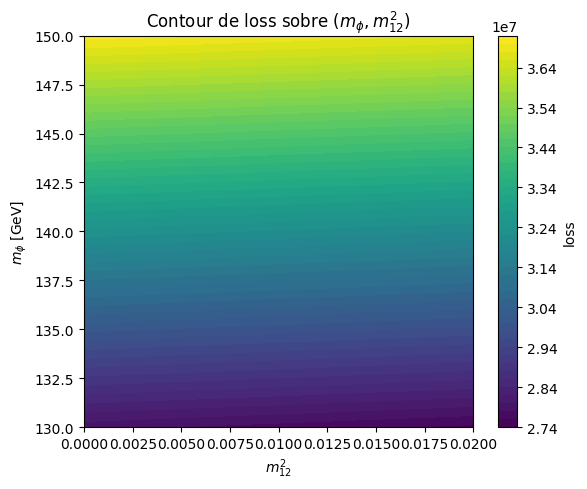

In [ ]:

# 3a) Heatmap con imshow
plt.figure(figsize=(6,5))
extent = [m12_vals[0], m12_vals[-1], mphi_vals[0], mphi_vals[-1]]
plt.imshow(
    loss_mat,
    origin='lower',
    aspect='auto',
    extent=extent,
    cmap='viridis'
)
plt.colorbar(label='loss')
plt.xlabel(r'$m_{12}^2$')
plt.ylabel(r'$m_\phi$ [GeV]')
plt.title('Heatmap de loss sobre $(m_\\phi, m_{12}^2)$')
plt.tight_layout()
plt.show()


Usar sampling avanzado

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Mapeo de etiquetas con unidades
_LABELS = {
    'mphi':     r'$m_{\phi}\ \mathrm{[GeV]}$',
    'm12':      r'$m_{12}^2\ \mathrm{[GeV}^2\mathrm{]}$',
    'mA':       r'$m_{A}\ \mathrm{[GeV]}$',
    'lambda6':  r'$\lambda_6$',
    'lambda7':  r'$\lambda_7$',
    'sin_ba':   r'$\sin(\beta-\alpha)$',
    'tan_beta': r'$\tan\beta$',
}

def plot_lhs_scatter_3d(df, axes, color='loss', cmap='plasma', log_color=True):
    """
    Scatter 3D de las columnas en `axes` (longitud 3), coloreado por `color`.
    Ajusta límites y etiquetas con unidades automáticamente.
    
    df    : DataFrame con tus datos
    axes  : ['param_x', 'param_y', 'param_z']
    color : columna a usar para colorear (por defecto 'loss')
    """
    # Extraer arrays
    xs = df[axes[0]].values
    ys = df[axes[1]].values
    zs = df[axes[2]].values
    cs = df[color].values
    if log_color:
        cs_plot = np.log10(cs)
        cbar_label = f'log10({color})'
    else:
        cs_plot = cs
        cbar_label = color

    # Crear figura
    fig = plt.figure(figsize=(7,6))
    ax  = fig.add_subplot(111, projection='3d')

    sc = ax.scatter(xs, ys, zs,
                    c=cs_plot, cmap=cmap,
                    s=50, edgecolor='k', depthshade=True)

    # Etiquetas con unidades
    ax.set_xlabel(_LABELS.get(axes[0], axes[0]))
    ax.set_ylabel(_LABELS.get(axes[1], axes[1]))
    ax.set_zlabel(_LABELS.get(axes[2], axes[2]))

    # Límites reales
    ax.set_xlim(xs.min(), xs.max())
    ax.set_ylim(ys.min(), ys.max())
    ax.set_zlim(zs.min(), zs.max())

    # Colorbar
    cbar = fig.colorbar(sc, pad=0.1, shrink=0.7)
    cbar.set_label(cbar_label)

    ax.set_title(f'LHS Explorer: {cbar_label} en ({axes[0]}, {axes[1]}, {axes[2]})')

    plt.tight_layout()
    plt.show()


In [33]:
df_lhs

,mphi,m12,mA,sin_ba,tan_beta,lambda6,lambda7,loss
0,200.0,0.379472,300,0.973449,1.751972e+06,0.1,0.0,3.169929e+13
1,200.0,0.431764,300,0.984945,7.432689e+06,0.1,0.0,2.888606e+15
2,200.0,0.682895,300,0.012225,3.957205e+06,0.1,0.0,6.939877e+14
3,200.0,0.424940,300,0.668090,6.952845e+06,0.1,0.0,2.334817e+15
4,200.0,0.067440,300,0.143231,7.335082e+06,0.1,0.0,4.247067e+14
...,...,...,...,...,...,...,...,...
1995,200.0,0.753187,300,0.350539,5.195674e+06,0.1,0.0,1.734237e+15
1996,200.0,0.168745,300,0.294762,4.980038e+06,0.1,0.0,3.365205e+14
1997,200.0,0.818957,300,0.882882,6.069192e+06,0.1,0.0,2.998950e+15
1998,200.0,0.089885,300,0.853003,5.929060e+06,0.1,0.0,2.896832e+14


In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from skopt import Space
from skopt.space import Real
from skopt.sampler import Lhs

from lib.advanced.calling_utils import OracleExecutor

# --------------------------------------------------
# a.1) Parámetros globales
# --------------------------------------------------

# a.2) Fijar sólo las columnas que no queremos explorar en el scatter
#    En este caso vamos a explorar ['m12','mA','tan_beta']
axes = ['m12','sin_ba','mA']

fixed = {
    'mphi':    200.0,    # o el valor que quieras fijar aquí
    #'sin_ba':  1.0,
    'tan_beta': 1e4,
    'lambda6': 0.1,
    'lambda7': 0.0,
    #'mA': 300
}

n_samples = 2000 # muestras de LHS

# --------------------------------------------------
# 1) Definir el espacio de búsqueda LHS
# --------------------------------------------------
search_space = [
    Real(130.0, 150.0,   name='mphi'),
    Real(0.0,   1.0,    name='m12'),
    Real(300.0, 500.0,   name='mA'),
    Real(0.0,   1,  name='sin_ba'),
    Real(1e3,   1e7,     name='tan_beta'),
    Real(0.0,   1.0,     name='lambda6'),
    Real(0.0,   1.0,     name='lambda7'),
]



# =----=====================================----------=

executor = OracleExecutor(nthreads=4)



# _PARAM_ORDER definido en threading.py:
_PARAM_ORDER = [
    'mphi','mA','sin_ba','tan_beta','lambda6','lambda7','m12'
]


space = Space(search_space)
lhs = Lhs(criterion="maximin", iterations=500)
X_lhs = lhs.generate(space.dimensions, n_samples)

# ======================================================#
# 2) Convertir a DataFrame para manipular columnas
df_lhs = pd.DataFrame(X_lhs, columns=space.dimension_names)


others = [p for p in _PARAM_ORDER if p not in axes]
# rellena df_lhs con los valores fijos para esas otras columnas
for p in others:
    df_lhs[p] = fixed[p]

# 4) Preparar la lista de parámetros en el orden correcto
param_list = df_lhs[_PARAM_ORDER].values.tolist()

# 5) Evaluar todo con OracleExecutor en batch
outs = executor.run_batch(param_list)

# 6) Calcular la métrica (loss) para cada salida
def loss_results(out) -> float:
    if out.get('error') is not None:
        return np.inf
    return (abs(out['lambda1']) + abs(out['lambda2']) +
            abs(out['lambda3']) + abs(out['lambda4']) +
            abs(out['lambda5']))

df_lhs['loss'] = [loss_results(o) for o in outs]




2025-04-28 03:31:19,273 [DEBUG] locator: <matplotlib.ticker.AutoLocator object at 0x7f216cc7be20>


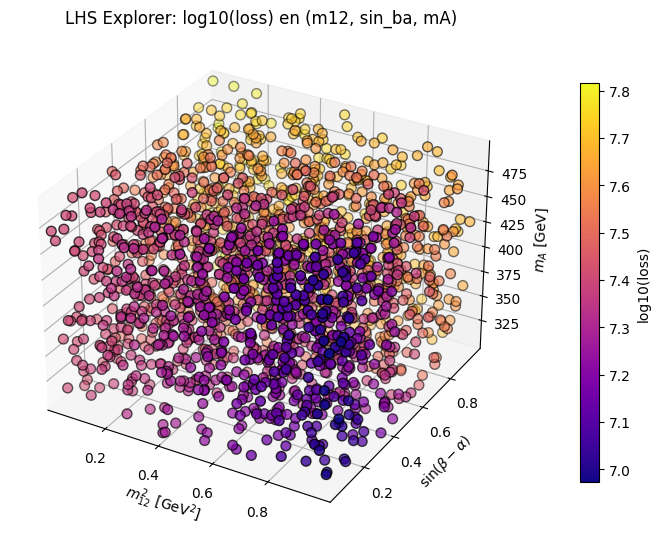

In [36]:

plot_lhs_scatter_3d(df_lhs, axes, color='loss', cmap='plasma')


# Crear LHS para asi generar un modelo surrogativo y apliacr ML

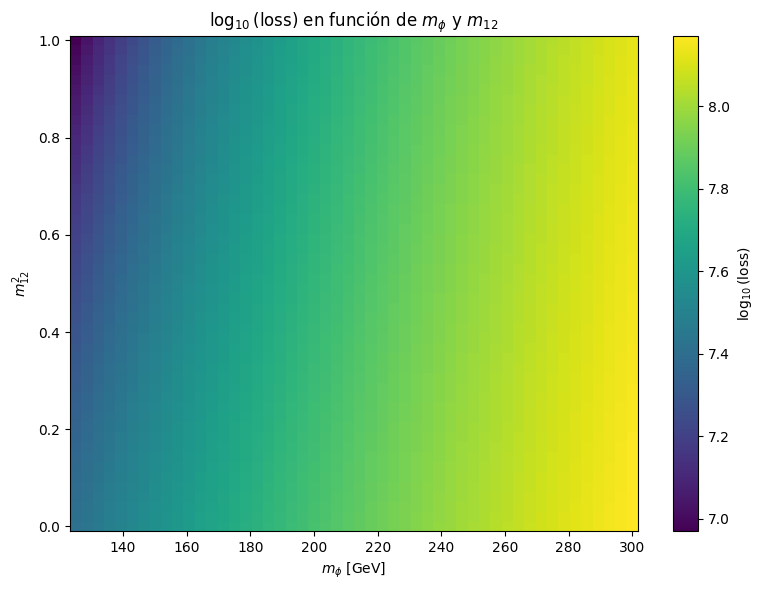

In [3]:
# Objetivo 2:
# mapa de color tipo log(loss), ejes horizontal, vertical: mphi, m12


# Definir rejilla
n_phi  = 50
n_m12  = 50
mphi_v = np.linspace(125.1, 300.0, n_phi)
m12_v  = np.linspace(0,  1.0,   n_m12)
mA_v = np.linspace(300, 500.0, n_phi)

# Matriz de pérdidas
L = np.empty((n_m12, n_phi))
L[:] = np.nan

for i, m12 in enumerate(m12_v):
    for j, mphi in enumerate(mphi_v):
    # for j, mA in enumerate(mA_v):
        val = loss(mphi, m12)
        L[i,j] = val
        # try:
        #     val = loss(mphi, m12)
        # except Exception:
        #     L[i,j] = np.nan
        # else:
        #     L[i,j] = val

# Tomamos log y enmascaramos valores demasiado grandes (por ej. >1e3)
with np.errstate(divide='ignore'):
    Z = np.log10(L)
    #Z = L
#Z[L > 1e3] = np.nan


# # Plot
plt.figure(figsize=(8,6))
# pcolormesh requiere mallas “extendidas”
X, Y = np.meshgrid(mphi_v, m12_v)
pcm = plt.pcolormesh(X, Y, Z, shading='auto')
plt.xlabel(r'$m_\phi$ [GeV]')
plt.ylabel(r'$m_{12}^2$')
plt.title(r'$\log_{10}(\mathrm{loss})$ en función de $m_\phi$ y $m_{12}$')
plt.colorbar(pcm, label=r'$\log_{10}(\mathrm{loss})$')
plt.tight_layout()
plt.show()


## ajuste fino y cercano a 0 de $m_{12}^2$

In [ ]:
# Definir rejilla
n_phi  = 100
n_m12  = 100
mphi_v = np.linspace(125.1, 300.0, n_phi)
m12_v  = np.linspace(0,  0.01,   n_m12)

# Matriz de pérdidas
L = np.empty((n_m12, n_phi))
L[:] = np.nan

for i, m12 in enumerate(m12_v):
    for j, mphi in enumerate(mphi_v):
        val = loss(mphi, m12)
        L[i,j] = val

# Tomamos log y enmascaramos valores demasiado grandes (por ej. >1e3)
with np.errstate(divide='ignore'):
    Z = np.log10(L)


# # Plot
plt.figure(figsize=(8,6))
X, Y = np.meshgrid(mphi_v, m12_v)
pcm = plt.pcolormesh(X, Y, Z, shading='auto')
plt.xlabel(r'$m_\phi$ [GeV]')
plt.ylabel(r'$m_{12}$')
plt.title(r'$\log_{10}(\mathrm{loss})$ en función de $m_\phi$ y $m_{12}$')
plt.colorbar(pcm, label=r'$\log_{10}(\mathrm{loss})$')
plt.tight_layout()
plt.show()


# Experimental:

## Ajuste polinomial
Un experimento para conseguir una ecuacion del plano

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from lib.oracle import safe_run_oracle
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D


# Definición de rejillas
n_phi = 10
n_m12 = 10
n_mA  = 10

mphi_vals = np.linspace(125.1, 300.0, n_phi)
m12_vals  = np.linspace(0,   1.0,   n_m12)
mA_vals   = np.linspace(200.0,  400.0, n_mA)

# Matrices para almacenar mA* y la pérdida mínima
MA_min = np.empty((n_m12, n_phi))
Loss_min = np.empty_like(MA_min)

# Búsqueda del mínimo en mA para cada (mφ, m12)
for i, m12 in enumerate(m12_vals):
    for j, mphi in enumerate(mphi_vals):
        # calcular pérdidas para cada mA
        vals = []
        for mA in mA_vals:
            vals.append(loss(mphi, m12, mA))

        vals = np.array(vals)
        idx = np.nanargmin(vals)
        MA_min[i, j] = mA_vals[idx]
        Loss_min[i, j] = vals[idx]

# Ajuste polinomial a grado 3
X = np.vstack([
    np.repeat(mphi_vals, n_m12),
    np.tile(m12_vals, n_phi)
]).T  # Forma (n_phi*n_m12, 2)
y = MA_min.ravel()

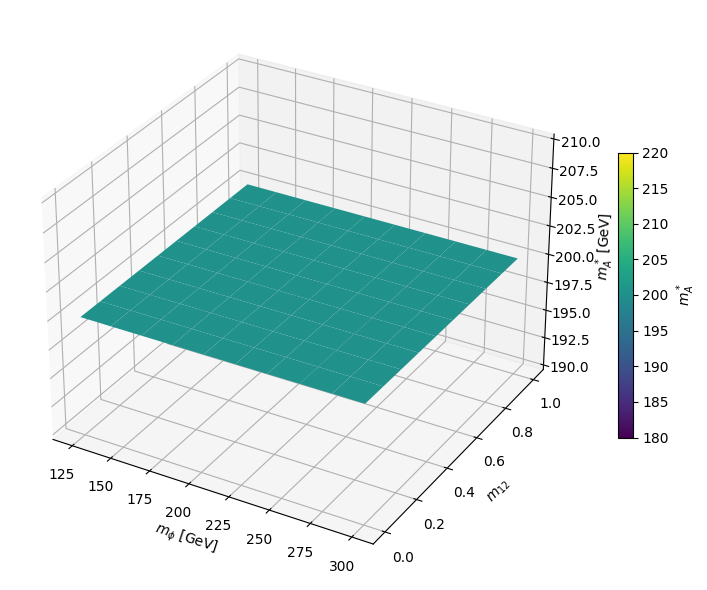

Modelo ajustado: mA* =
  +0.000e+00 * 1
  +0.000e+00 * mphi
  +0.000e+00 * m12
  +0.000e+00 * mphi^2
  +0.000e+00 * mphi m12
  +0.000e+00 * m12^2
  +0.000e+00 * mphi^3
  +0.000e+00 * mphi^2 m12
  +0.000e+00 * mphi m12^2
  +0.000e+00 * m12^3
  +2.000e+02  (intercept)


In [7]:


poly = PolynomialFeatures(degree=3, include_bias=True)
Xp   = poly.fit_transform(X)
reg  = LinearRegression().fit(Xp, y)

# Visualización 3D de la superficie mA*(mφ, m12)
fig = plt.figure(figsize=(8,6))
ax  = fig.add_subplot(111, projection='3d')
Phi, M12 = np.meshgrid(mphi_vals, m12_vals)
surf = ax.plot_surface(Phi, M12, MA_min, cmap='viridis', edgecolor='none')
ax.set_xlabel(r'$m_\phi$ [GeV]')
ax.set_ylabel(r'$m_{12}$')
ax.set_zlabel(r'$m_A^*$ [GeV]')
fig.colorbar(surf, ax=ax, shrink=0.5, label=r'$m_A^*$')
plt.tight_layout()
plt.show()

# Imprimir coeficientes del polinomio ajustado
terms     = poly.get_feature_names_out(['mphi','m12'])
coefs     = reg.coef_
intercept = reg.intercept_

print("Modelo ajustado: mA* =")
for t, c in zip(terms, coefs):
    print(f"  {c:+.3e} * {t}")
print(f"  {intercept:+.3e}  (intercept)")
